In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("../data/tanzania.csv")
df["Country"] = "Tanzania"

In [5]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month

In [6]:
df.replace(-999, np.nan, inplace=True)

In [7]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

Duplicate rows: 0


In [8]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


In [9]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


In [10]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(zscore(df[cols], nan_policy='omit'))
outliers = (z_scores > 3).sum()

print(outliers)

102


In [11]:
df = df.fillna(method="ffill")

# Optional: drop rows with too many missing values
df = df[df.isna().mean(axis=1) < 0.3]

C:\Users\Alienware\AppData\Local\Temp\ipykernel_48176\1397755152.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


In [12]:
df.to_csv("../data/tanzania_clean.csv", index=False)

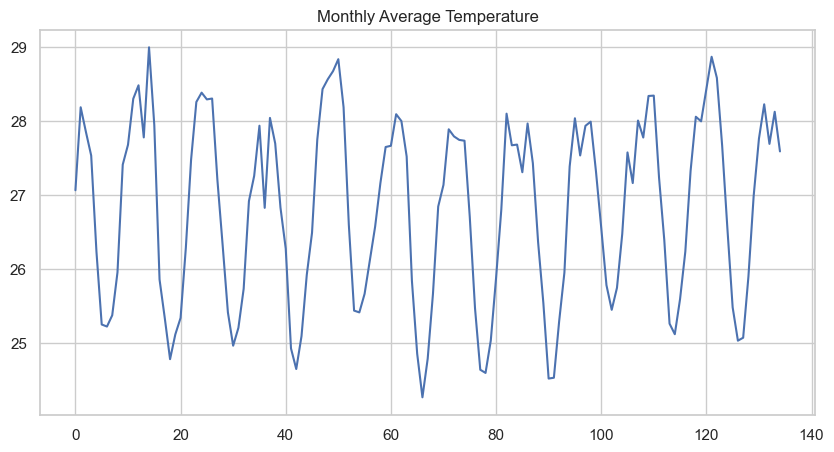

In [13]:
monthly_temp = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp["T2M"])
plt.title("Monthly Average Temperature")
plt.show()

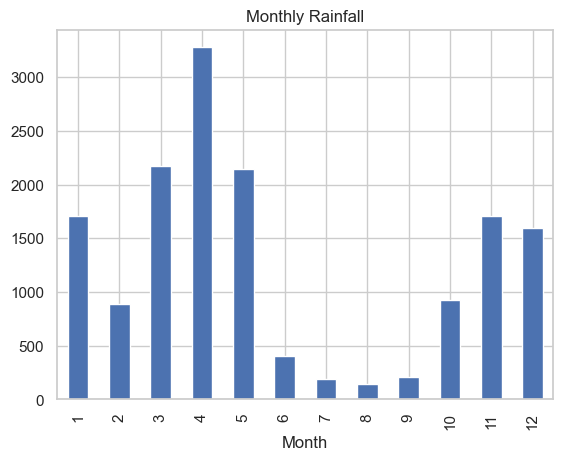

In [14]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Rainfall")
plt.show()

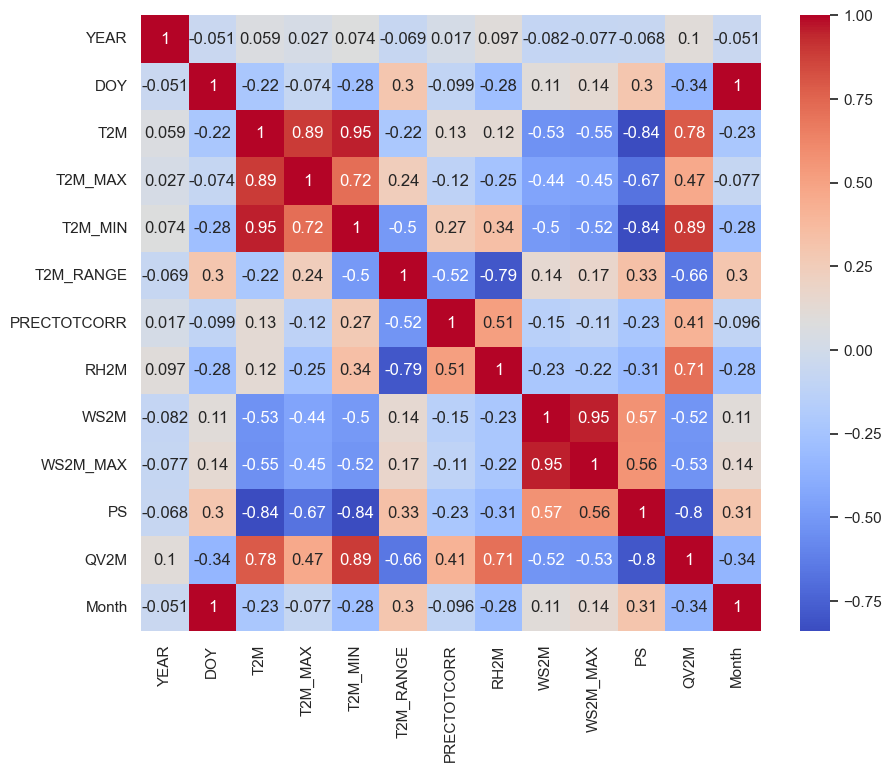

In [15]:
corr = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

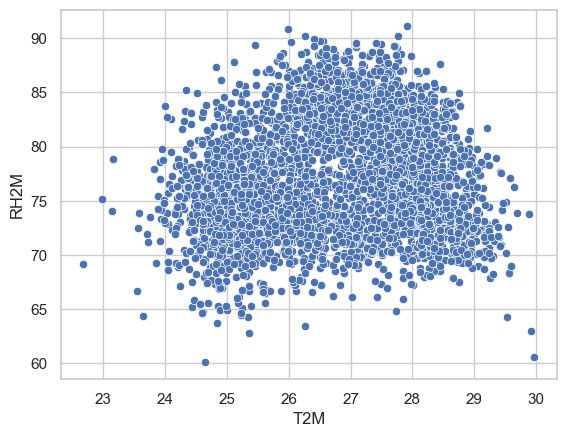

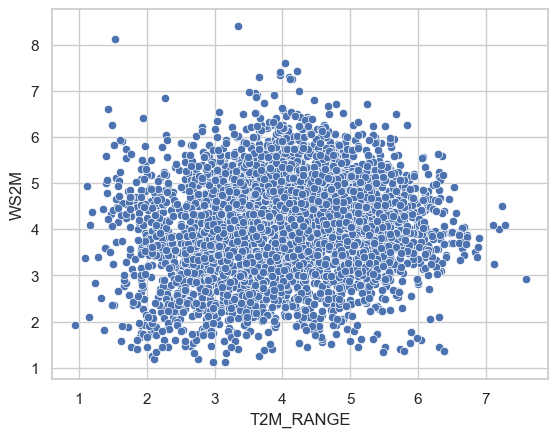

In [16]:
sns.scatterplot(x="T2M", y="RH2M", data=df)
plt.show()

sns.scatterplot(x="T2M_RANGE", y="WS2M", data=df)
plt.show()

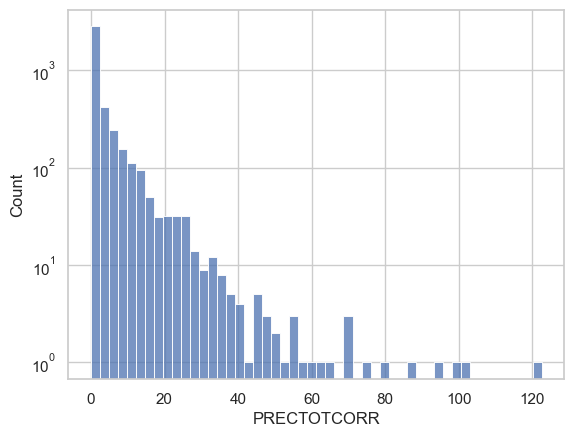

In [17]:
sns.histplot(df["PRECTOTCORR"], bins=50)
plt.yscale("log")
plt.show()

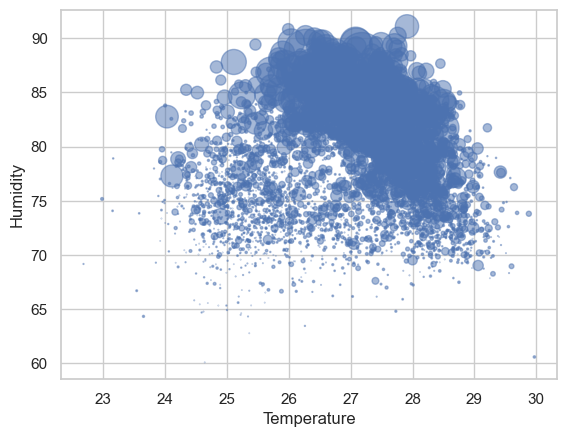

In [18]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*10, alpha=0.5)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()